In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Euler method function
def euler_method(h, x_start=0, x_end=10*np.pi):
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1  # y(0) = 1

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    return x_values, y_values

# Function representing dy/dx = -2y*cos(x)
def f(x, y):
    return -2 * y * np.cos(x)

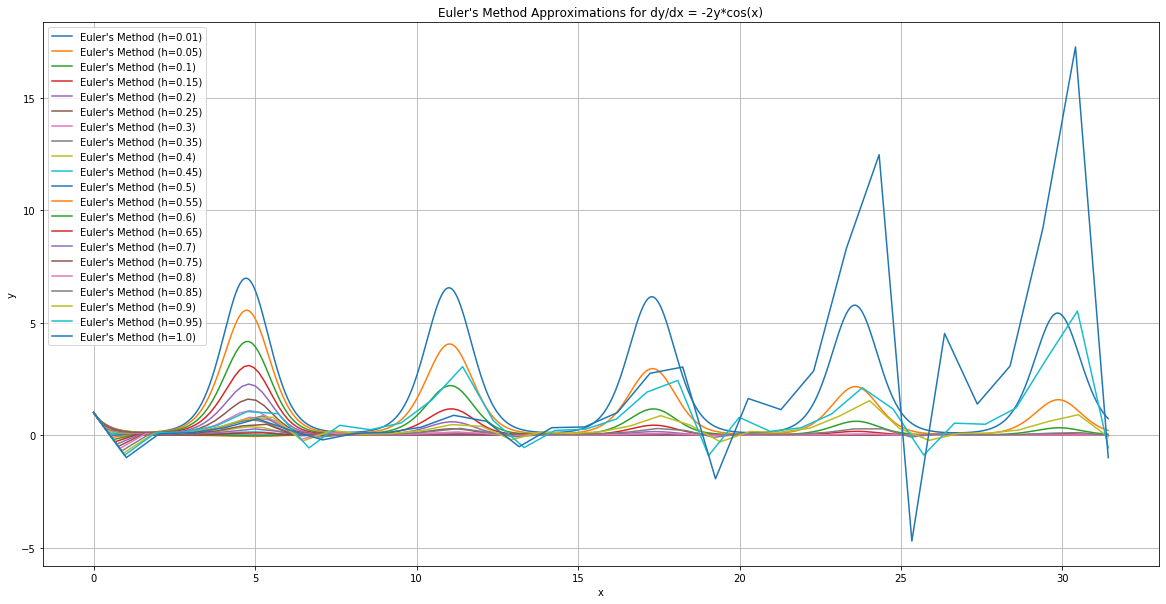

In [3]:
# Plotting different values of h vs. each other
h_values = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
plt.figure(figsize=(20,10))
for h in h_values:
    x_values, y_values = euler_method(h)
    plt.plot(x_values, y_values, label= f'Euler\'s Method (h={h})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Euler\'s Method Approximations for dy/dx = -2y*cos(x)')
plt.legend()
plt.grid(True)
plt.show()

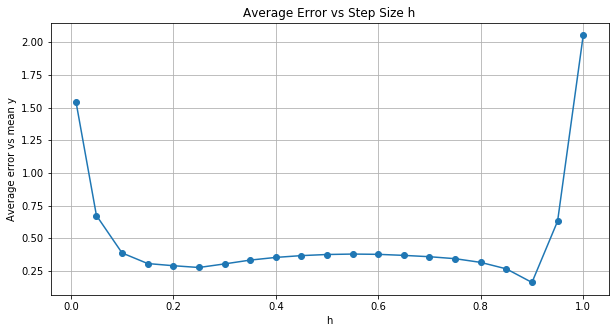

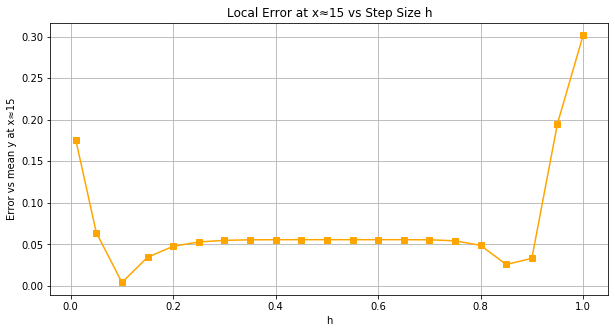

In [4]:
# Error Calculations

# Must first interpolate the different approximations as each h value will have a different amount of x and y values
x_common = np.linspace(0, 10*np.pi, 10000)

y_interpolated = []
for h in h_values:
    x_values, y_values = euler_method(h)
    y_interp = np.interp(x_common, x_values, y_values)
    y_interpolated.append(y_interp)

y_interpolated = np.array(y_interpolated)

# Calculate the mean y across all runs at each x point
y_mean = np.mean(y_interpolated, axis=0)  

# Calculate Average Error
avg_error_list = []
for i in range(len(h_values)):
    avg_error = np.mean(np.abs(y_interpolated[i] - y_mean))
    avg_error_list.append(avg_error)

# Local error at x≈15 vs the mean
local_error_list = []
idx = np.argmin(np.abs(x_common - 15))
for i in range(len(h_values)):
    local_error = np.abs(y_interpolated[i, idx] - y_mean[idx])
    local_error_list.append(local_error)
    
# Plotting
plt.figure(figsize=(10, 5))
plt.plot(h_values, avg_error_list, 'o-')
plt.xlabel('h')
plt.ylabel('Average error vs mean y')
plt.title('Average Error vs Step Size h')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(h_values, local_error_list, 's-', color='orange')
plt.xlabel('h')
plt.ylabel('Error vs mean y at x≈15')
plt.title('Local Error at x≈15 vs Step Size h')
plt.grid(True)
plt.show()

I think that error shown makes sense. For the lowest values of h, the error is somewhat higher than most of the rest of the h values. This is because the rest of the h values influence the average outputted y to be somewhat inaccurate to the exact solution, meaning both the most accurate approximation (the lowest h values) and the least accurate (the highest h values) will exhibit the greatest error.

## Addendum:

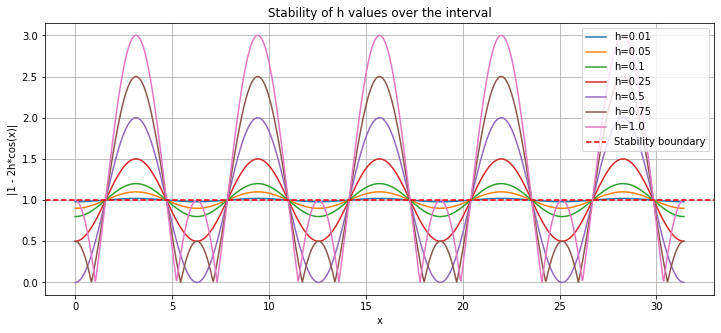

In [5]:
x_values = np.linspace(0, 10*np.pi, 1000)
# Lambda = -2*cos(x)
# Stability Condition is |1-2h*cos(x)| <= 1; functionally h <= 1; explains why approximations start to drift and blow up as h approaches 1
# Because of the cos(x), stability is variable; certain x's are more or less stable for certain h's; the closer an h is to 0, the more stable it is overall
plt.figure(figsize=(12, 5))
for h in [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0]:
    stability = np.abs(1 - 2*h*np.cos(x_values))
    plt.plot(x_values, stability, label=f'h={h}')
plt.axhline(1, color='red', linestyle='--', label='Stability boundary')
plt.xlabel('x')
plt.ylabel('|1 - 2h*cos(x)|')
plt.title('Stability of h values over the interval')
plt.legend()
plt.grid(True)
plt.show()